## 1. 环境准备

导入必要的库并配置中文字体支持。

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from matplotlib import rcParams

# ================== 全局环境配置 ==================
# 配置 matplotlib 使用中文字体
# 注意：run_jupyterlab.sh 已通过挂载 matplotlibrc 文件进行全局配置
# 这里再次配置是为了确保在非 Docker 环境（如本地直接运行）下也能正确显示中文
def config_fonts():
    try:
        # 尝试多种常用中文字体，优先使用挂载的字体
        # SimHei: Windows标准/Docker挂载
        # Heiti TC: Mac标准
        fonts = ['SimHei', 'Heiti TC', 'WenQuanYi Micro Hei', 'DejaVu Sans']
        rcParams['font.sans-serif'] = fonts
        rcParams['axes.unicode_minus'] = False  # 解决负号显示问题
    except:
        pass

config_fonts()
print("环境配置完成，中文字体已设置。")

环境配置完成，中文字体已设置。


## 2. 生成模拟数据

为了演示线性回归，我们首先生成一个模拟的房价数据集。该数据集包含房屋面积 (`sqft`) 和卧室数量 (`bedrooms`) 作为特征，以及房价 (`price`) 作为目标变量。

In [26]:
# 1. 创建数据
np.random.seed(42)  # 为了可重复性
num_samples = 47  # 样本数量

# 房屋面积（平方英尺）
areas = np.random.randint(1000, 3500, num_samples)

# 卧室数量
bedrooms = np.random.randint(2, 5, num_samples)

# 基础价格，加上一些噪声
base_price = 100000  # 基础价格
price_per_sqft = 100  # 每平方英尺价格
price_per_bedroom = 15000  # 每个卧室价格
noise = np.random.normal(0, 10000, num_samples)  # 添加噪声

prices = base_price + areas * price_per_sqft + bedrooms * price_per_bedroom + noise

# 2. 创建数据框
data = pd.DataFrame({
    'sqft': areas,
    'bedrooms': bedrooms,
    'price': prices.astype(int)  # 将价格四舍五入为整数
})

# 3. 保存为 CSV 文件
data.to_csv('house_prices.csv', index=False)

print("数据集已生成并保存为 house_prices.csv")

数据集已生成并保存为 house_prices.csv


## 3. 线性回归模型训练与评估

本部分展示线性回归的完整流程：
1.  **数据加载与预览**：读取生成的 CSV 文件。
2.  **数据预处理**：标准化特征数据，消除量纲影响。
3.  **数据集划分**：将数据划分为训练集和测试集。
4.  **模型训练**：使用 `LinearRegression` 拟合训练数据。
5.  **模型评估**：计算均方误差 (MSE) 和决定系数 ($R^2$)。
6.  **结果可视化**：绘制预测值与真实值的散点图。
7.  **新数据预测**：对新房屋样本进行价格预测。

数据集前几行：
    sqft  bedrooms   price
0  1860         4  352363
1  2294         4  380332
2  2130         2  347760
3  2095         4  382536
4  2638         4  425915
模型参数：
截距 (theta0): 380496.07
标准化后的系数 (theta1, theta2): [71305.9841922 11566.3096624]

模型评估：
均方误差 (MSE): 126378189.15
决定系数 (R^2): 0.98


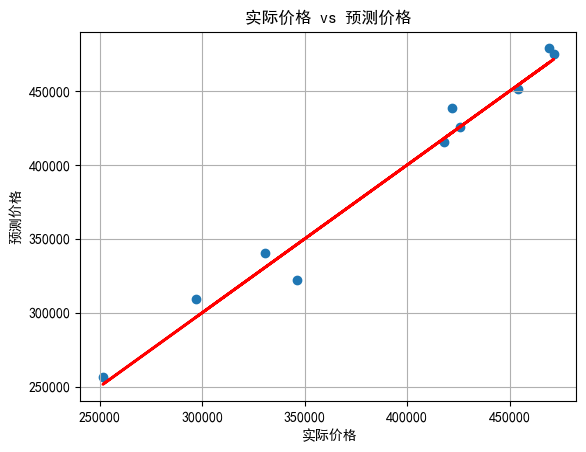


新房子预测价格：$346999.60


In [27]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler  # 新增标准化模块
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# 1. 加载数据集
data = pd.read_csv('house_prices.csv')  # 假设数据集文件名为 house_prices.csv，列名需与实际数据匹配（如英文列名：'sqft', 'bedrooms', 'price'）

# 预览数据集的前几行，检查数据格式
print("数据集前几行：\n", data.head())

# 2. 数据预处理
# 特征变量和目标变量
X = data[['sqft', 'bedrooms']]  # 若列名为中文，需调整为实际列名（如“面积”）
y = data['price']

# 3. 数据标准化（解决量纲差异问题）
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)  # 将特征标准化为均值为0，标准差为1

# 4. 数据集划分
# 将数据集划分为训练集和测试集，测试集占比 20%
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# 5. 创建线性回归模型
model = LinearRegression()

# 6. 训练模型
model.fit(X_train, y_train)

# 7. 预测
y_pred = model.predict(X_test)

# 8. 输出模型参数
print("模型参数：")
print("截距 (theta0): {:.2f}".format(model.intercept_))
print("标准化后的系数 (theta1, theta2): {}".format(model.coef_))

# 9. 评估模型
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("\n模型评估：")
print("均方误差 (MSE): {:.2f}".format(mse))
print("决定系数 (R^2): {:.2f}".format(r2))

# 10. 可视化结果
plt.scatter(y_test, y_pred)
plt.xlabel("实际价格")
plt.ylabel("预测价格")
plt.title("实际价格 vs 预测价格")
plt.plot(y_test, y_test, color='red', linewidth=2)  # 对角线
plt.grid()
plt.show()

# 11. 预测新数据
# 假设有一套面积为 2000 平方英尺，3 个卧室的房子
new_house = pd.DataFrame([[2000, 3]], columns=['sqft', 'bedrooms'])  # 创建一个包含特征名称的 DataFrame

new_house_scaled = scaler.transform(new_house)  # 标准化新数据
predicted_price = model.predict(new_house_scaled)
print("\n新房子预测价格：${:.2f}".format(predicted_price[0]))

## 4. 进阶：正则化 (Regularization)

正如教案中所述，当存在多重共线性或需要提升泛化能力时，可以使用正则化方法。
这里展示 Ridge (L2) 和 Lasso (L1) 的简单应用。

In [28]:
from sklearn.linear_model import Ridge, Lasso

print("\n=== 正则化模型对比 ===")

# Ridge 回归 (L2 正则化)
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)
ridge_pred = ridge_model.predict(X_test)
print(f"Ridge MSE: {mean_squared_error(y_test, ridge_pred):.2f}")
print(f"Ridge Coef: {ridge_model.coef_}")

# Lasso 回归 (L1 正则化)
lasso_model = Lasso(alpha=0.1)
lasso_model.fit(X_train, y_train)
lasso_pred = lasso_model.predict(X_test)
print(f"Lasso MSE: {mean_squared_error(y_test, lasso_pred):.2f}")
print(f"Lasso Coef: {lasso_model.coef_}")


=== 正则化模型对比 ===
Ridge MSE: 123257754.14
Ridge Coef: [69306.6330693 11058.1535084]
Lasso MSE: 126378219.19
Lasso Coef: [71305.86585163 11566.19832794]


In [29]:
# 删除生成的临时文件
import os
if os.path.exists('house_prices.csv'):
    os.remove('house_prices.csv')
    print("文件 house_prices.csv 已删除")

文件 house_prices.csv 已删除
